# Module 4: Biometric Evaluation Metrics

| | |
|---|---|
| **Project** | Face Verification Pipeline -- AgeDB-30 / LFW |
| **Notebook** | `notebooks/04_evaluate.ipynb` |
| **Date** | 2026-03-16 |
| **Dependencies** | Module 3 (`03_compare_pairs.ipynb`) |
| **Input** | `results/distances_{model}_{dataset}.csv` (4 files, 6 000 rows each) |
| **Output** | `results/evaluation_metrics.csv`, `notebooks/evaluation_output/roc_curves.png`, `notebooks/evaluation_output/score_distributions.png`, `notebooks/evaluation_output/roc_logscale.png`, `notebooks/evaluation_output/summary_table.png` |

---

## Objective

This module constitutes the formal evaluation layer of the pipeline. Given pairwise
cosine similarity scores produced in Module 3, it computes the full set of
standard biometric verification metrics:

- **ROC curve** and **AUC** (Area Under the Curve),
- **EER** (Equal Error Rate) and the corresponding decision threshold,
- **TAR @ FAR** at three operating points: $10^{-2}$, $10^{-3}$, $10^{-4}$.

Results are reported for both models (ArcFace / buffalo_l and GhostFaceNetV2)
on both datasets (AgeDB-30 and LFW), for a total of four experimental conditions.
All figures are publication-ready.

## 1. Configuration and Imports

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from sklearn.metrics import auc as sklearn_auc
from sklearn.metrics import roc_curve

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "figure.facecolor": "white",
    }
)

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "evaluation_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["agedb", "lfw"]
MODELS = ["arcface", "ghostface"]

MODEL_LABELS = {
    "arcface": "ArcFace (buffalo_l / w600k_r50)",
    "ghostface": "GhostFaceNetV2",
}
MODEL_COLORS = {
    "arcface": "#1976D2",
    "ghostface": "#D32F2F",
}
DS_LABELS = {"agedb": "AgeDB-30", "lfw": "LFW"}
DS_LINESTYLES = {"agedb": "-", "lfw": "--"}

FAR_TARGETS = [1e-2, 1e-3, 1e-4]
FAR_LABELS = [r"FAR=$10^{-2}$", r"FAR=$10^{-3}$", r"FAR=$10^{-4}$"]
FAR_COLORS = ["#FF8F00", "#E65100", "#B71C1C"]

print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUTPUT_DIR}")

missing = [
    str(RESULTS_DIR / f"distances_{m}_{ds}.csv")
    for m in MODELS
    for ds in DATASETS
    if not (RESULTS_DIR / f"distances_{m}_{ds}.csv").exists()
]
if missing:
    raise FileNotFoundError("Missing Module 3 outputs:\n" + "\n".join(missing))
print(f"\nInput files verified ({len(MODELS) * len(DATASETS)} files).")

Project root : /Users/jakub/Desktop/NASK_ZADANIE
Output dir   : /Users/jakub/Desktop/NASK_ZADANIE/notebooks/evaluation_output

Input files verified (4 files).


## 2. Mathematical Framework

### 2.1 Verification as Binary Classification

The face verification problem is cast as binary classification on a scalar
score $s \in \mathbb{R}$: for a pair $(i, j)$, $y \in \{0, 1\}$ indicates
impostor vs. genuine, and the model outputs cosine similarity
$s = \hat{e}_i \cdot \hat{e}_j$ (on L2-normalized embeddings).

### 2.2 Receiver Operating Characteristic (ROC)

For threshold $\tau$, define the confusion matrix:

$$
\text{FAR}(\tau) = \frac{\text{FP}(\tau)}{\text{N}}, \qquad
\text{TAR}(\tau) = \frac{\text{TP}(\tau)}{\text{P}}
$$

where $P$ = number of genuine pairs and $N$ = number of impostor pairs.
TAR is equivalent to TPR, and FAR is equivalent to FPR.

The ROC curve traces $\bigl(\text{FAR}(\tau),\, \text{TAR}(\tau)\bigr)$
as $\tau$ varies. The AUC summarises discrimination ability:

$$
\text{AUC} = \int_0^1 \text{TAR}\bigl(\text{FAR}^{-1}(t)\bigr)\, \mathrm{d}t
\in [0, 1]
$$

A perfect classifier achieves $\text{AUC} = 1$; a random classifier achieves
$\text{AUC} = 0.5$.

### 2.3 Equal Error Rate (EER)

The EER is the operating point where FAR = FRR:

$$
\text{EER} = \text{FAR}(\tau^*) = \text{FRR}(\tau^*), \qquad
\text{FRR}(\tau) = 1 - \text{TAR}(\tau)
$$

Since FAR and FRR are discrete functions of $\tau$, the EER is approximated
as the average at the crossing index:

$$
k^* = \arg\min_k \bigl|\text{FAR}_k - \text{FNR}_k\bigr|, \qquad
\text{EER} = \frac{\text{FAR}_{k^*} + \text{FNR}_{k^*}}{2}
$$

Lower EER indicates better performance. State-of-the-art models on LFW achieve
EER $< 0.5\%$.

### 2.4 TAR at Fixed FAR (Operating Point Analysis)

For security applications, the FAR is fixed at a specification level and the
system's TAR (sensitivity) at that operating point is measured:

$$
\text{TAR@FAR} = \text{TAR}\bigl(\tau^{\text{op}}\bigr), \qquad
\tau^{\text{op}} = \inf\{\tau : \text{FAR}(\tau) \leq \text{FAR}^{\text{target}}\}
$$

We report three standard operating points:
$\text{FAR} \in \{10^{-2},\, 10^{-3},\, 10^{-4}\}$.

## 3. Load Pairwise Scores from Module 3

In [2]:
score_data = {}  # (model, dataset) -> DataFrame

for m in MODELS:
    for ds in DATASETS:
        df = pd.read_csv(RESULTS_DIR / f"distances_{m}_{ds}.csv")
        assert set(df.columns) >= {"true_label", "cosine_similarity"}, f"Unexpected schema in distances_{m}_{ds}.csv"
        score_data[(m, ds)] = df

print("Table 1. Loaded Score Files\n")
rows = []
for m in MODELS:
    for ds in DATASETS:
        df = score_data[(m, ds)]
        s = df["cosine_similarity"]
        rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": DS_LABELS[ds],
                "Pairs": len(df),
                "Genuine": int(df["true_label"].sum()),
                "Impostor": int((df["true_label"] == 0).sum()),
                "Score range": f"[{s.min():.3f}, {s.max():.3f}]",
            }
        )

print(pd.DataFrame(rows).to_string(index=False))

Table 1. Loaded Score Files

                          Model  Dataset  Pairs  Genuine  Impostor     Score range
ArcFace (buffalo_l / w600k_r50) AgeDB-30   6000     3000      3000 [-0.191, 0.803]
ArcFace (buffalo_l / w600k_r50)      LFW   6000     3000      3000 [-0.177, 0.964]
                 GhostFaceNetV2 AgeDB-30   6000     3000      3000 [-0.235, 0.806]
                 GhostFaceNetV2      LFW   6000     3000      3000 [-0.244, 0.978]


### 3.1 Sanity Check: Class Balance

Both AgeDB-30 and LFW protocols are balanced: 3 000 genuine and 3 000 impostor
pairs. A balanced protocol ensures AUC is a fair summary statistic independent
of prior probabilities.

In [3]:
print("Class balance verification:\n")
for m in MODELS:
    for ds in DATASETS:
        df = score_data[(m, ds)]
        n_g = int(df["true_label"].sum())
        n_i = int((df["true_label"] == 0).sum())
        ratio = n_g / n_i
        status = "PASS" if abs(ratio - 1.0) < 1e-9 else "FAIL"
        print(
            f"  {MODEL_LABELS[m]:30s} / {DS_LABELS[ds]:8s}: "
            f"genuine={n_g}, impostor={n_i}, ratio={ratio:.3f}  [{status}]"
        )

Class balance verification:

  ArcFace (buffalo_l / w600k_r50)     / AgeDB-30: genuine=3000, impostor=3000, ratio=1.000  [PASS]
  ArcFace (buffalo_l / w600k_r50)     / LFW     : genuine=3000, impostor=3000, ratio=1.000  [PASS]
  GhostFaceNetV2                      / AgeDB-30: genuine=3000, impostor=3000, ratio=1.000  [PASS]
  GhostFaceNetV2                      / LFW     : genuine=3000, impostor=3000, ratio=1.000  [PASS]


## 4. ROC Curve Computation

The ROC curve is computed using `sklearn.metrics.roc_curve` with
`y_scores = cosine_similarity` (higher scores indicate genuine).
AUC is obtained via the trapezoidal rule applied to the discrete curve.

In [4]:
roc_data = {}  # (model, dataset) -> {"fpr", "tpr", "thresholds", "auc"}

for m in MODELS:
    for ds in DATASETS:
        df = score_data[(m, ds)]
        y_true = df["true_label"].values
        y_scores = df["cosine_similarity"].values

        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc = sklearn_auc(fpr, tpr)

        roc_data[(m, ds)] = {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds": thresholds,
            "auc": roc_auc,
        }

print("ROC curves computed (number of operating points per curve):\n")
for m in MODELS:
    for ds in DATASETS:
        rd = roc_data[(m, ds)]
        print(f"  {MODEL_LABELS[m]:35s} / {DS_LABELS[ds]:8s}: {len(rd['fpr']):5d} points,  AUC = {rd['auc']:.4f}")

ROC curves computed (number of operating points per curve):

  ArcFace (buffalo_l / w600k_r50)     / AgeDB-30:   658 points,  AUC = 0.9906
  ArcFace (buffalo_l / w600k_r50)     / LFW     :    20 points,  AUC = 0.9995
  GhostFaceNetV2                      / AgeDB-30:   732 points,  AUC = 0.9894
  GhostFaceNetV2                      / LFW     :    60 points,  AUC = 0.9988


## 5. Equal Error Rate (EER) and Optimal Threshold

The EER is computed at the index where $|\text{FAR}_k - \text{FNR}_k|$ is
minimal. The optimal decision threshold is the cosine similarity value at that
index. A lower EER corresponds to a better separator between the two classes.

In [5]:
eer_data = {}  # (model, dataset) -> {"eer", "eer_idx", "threshold", "far_at_eer", "fnr_at_eer"}

for m in MODELS:
    for ds in DATASETS:
        rd = roc_data[(m, ds)]
        fpr = rd["fpr"]
        tpr = rd["tpr"]
        fnr = 1.0 - tpr

        eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
        eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2.0)
        optimal_threshold = float(rd["thresholds"][eer_idx])

        eer_data[(m, ds)] = {
            "eer": eer,
            "eer_idx": eer_idx,
            "threshold": optimal_threshold,
            "far_at_eer": float(fpr[eer_idx]),
            "fnr_at_eer": float(fnr[eer_idx]),
        }

print("Table 2. EER and Optimal Threshold\n")
rows = []
for m in MODELS:
    for ds in DATASETS:
        ed = eer_data[(m, ds)]
        rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": DS_LABELS[ds],
                "EER": f"{ed['eer'] * 100:.2f}%",
                "FAR@EER": f"{ed['far_at_eer'] * 100:.2f}%",
                "FNR@EER": f"{ed['fnr_at_eer'] * 100:.2f}%",
                "Threshold": f"{ed['threshold']:.4f}",
            }
        )

print(pd.DataFrame(rows).to_string(index=False))

Table 2. EER and Optimal Threshold

                          Model  Dataset   EER FAR@EER FNR@EER Threshold
ArcFace (buffalo_l / w600k_r50) AgeDB-30 2.50%   2.50%   2.50%    0.1625
ArcFace (buffalo_l / w600k_r50)      LFW 0.33%   0.40%   0.27%    0.1881
                 GhostFaceNetV2 AgeDB-30 3.32%   3.30%   3.33%    0.1706
                 GhostFaceNetV2      LFW 0.57%   0.57%   0.57%    0.2188


## 6. TAR at Fixed FAR Operating Points

TAR is interpolated at each target FAR level using the discrete ROC curve.
The operating points $\text{FAR} \in \{10^{-2}, 10^{-3}, 10^{-4}\}$
correspond to real-world deployment scenarios ranging from border control
(FAR = 1%) to high-security access control (FAR = 0.01%).

In [6]:
tar_data = {}  # (model, dataset) -> {far_target: tar_value}


def tar_at_far(
    fpr: np.ndarray,
    tpr: np.ndarray,
    far_target: float,
) -> float:
    """
    Return the TAR at a fixed FAR target via stepwise interpolation.

    sklearn's roc_curve returns (fpr, tpr) in ascending fpr order.
    We find the first index where fpr >= far_target, then return the
    corresponding tpr.  This is the conservative (pessimistic) estimate:
    the TAR guaranteed at that FAR level.
    """
    idx = np.searchsorted(fpr, far_target, side="right")
    idx = min(idx, len(tpr) - 1)
    return float(tpr[idx])


for m in MODELS:
    for ds in DATASETS:
        rd = roc_data[(m, ds)]
        tar_data[(m, ds)] = {t: tar_at_far(rd["fpr"], rd["tpr"], t) for t in FAR_TARGETS}

print("Table 3. TAR at Fixed FAR Operating Points\n")
rows = []
for m in MODELS:
    for ds in DATASETS:
        td = tar_data[(m, ds)]
        rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": DS_LABELS[ds],
                "TAR@FAR=1%": f"{td[1e-2] * 100:.2f}%",
                "TAR@FAR=0.1%": f"{td[1e-3] * 100:.2f}%",
                "TAR@FAR=0.01%": f"{td[1e-4] * 100:.2f}%",
            }
        )

print(pd.DataFrame(rows).to_string(index=False))

Table 3. TAR at Fixed FAR Operating Points

                          Model  Dataset TAR@FAR=1% TAR@FAR=0.1% TAR@FAR=0.01%
ArcFace (buffalo_l / w600k_r50) AgeDB-30     96.77%       94.60%        94.43%
ArcFace (buffalo_l / w600k_r50)      LFW     99.80%       99.73%        99.73%
                 GhostFaceNetV2 AgeDB-30     95.30%       91.23%        75.20%
                 GhostFaceNetV2      LFW     99.50%       98.67%        95.73%


## 7. Export Consolidated Metrics to CSV

In [7]:
summary_rows = []
for m in MODELS:
    for ds in DATASETS:
        rd = roc_data[(m, ds)]
        ed = eer_data[(m, ds)]
        td = tar_data[(m, ds)]
        summary_rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": DS_LABELS[ds],
                "AUC": round(rd["auc"], 4),
                "EER": f"{ed['eer'] * 100:.2f}%",
                "Thr_EER": round(ed["threshold"], 4),
                "TAR@FAR=1%": f"{td[1e-2] * 100:.2f}%",
                "TAR@FAR=0.1%": f"{td[1e-3] * 100:.2f}%",
                "TAR@FAR=0.01%": f"{td[1e-4] * 100:.2f}%",
            }
        )

eval_df = pd.DataFrame(summary_rows)
eval_df.to_csv(RESULTS_DIR / "evaluation_metrics.csv", index=False)
print("Saved: results/evaluation_metrics.csv\n")
print(eval_df.to_string(index=False))

Saved: results/evaluation_metrics.csv

                          Model  Dataset    AUC   EER  Thr_EER TAR@FAR=1% TAR@FAR=0.1% TAR@FAR=0.01%
ArcFace (buffalo_l / w600k_r50) AgeDB-30 0.9906 2.50%   0.1625     96.77%       94.60%        94.43%
ArcFace (buffalo_l / w600k_r50)      LFW 0.9995 0.33%   0.1881     99.80%       99.73%        99.73%
                 GhostFaceNetV2 AgeDB-30 0.9894 3.32%   0.1706     95.30%       91.23%        75.20%
                 GhostFaceNetV2      LFW 0.9988 0.57%   0.2188     99.50%       98.67%        95.73%


## 8. Visualisation

### 8.1 ROC Curves with EER Operating Points

Each panel shows both models on one dataset. The EER point is marked with a
filled circle; the chance-level diagonal is plotted as a reference. The
random-chance baseline (AUC = 0.5) is shown in grey.

Saved: notebooks/evaluation_output/roc_curves.png


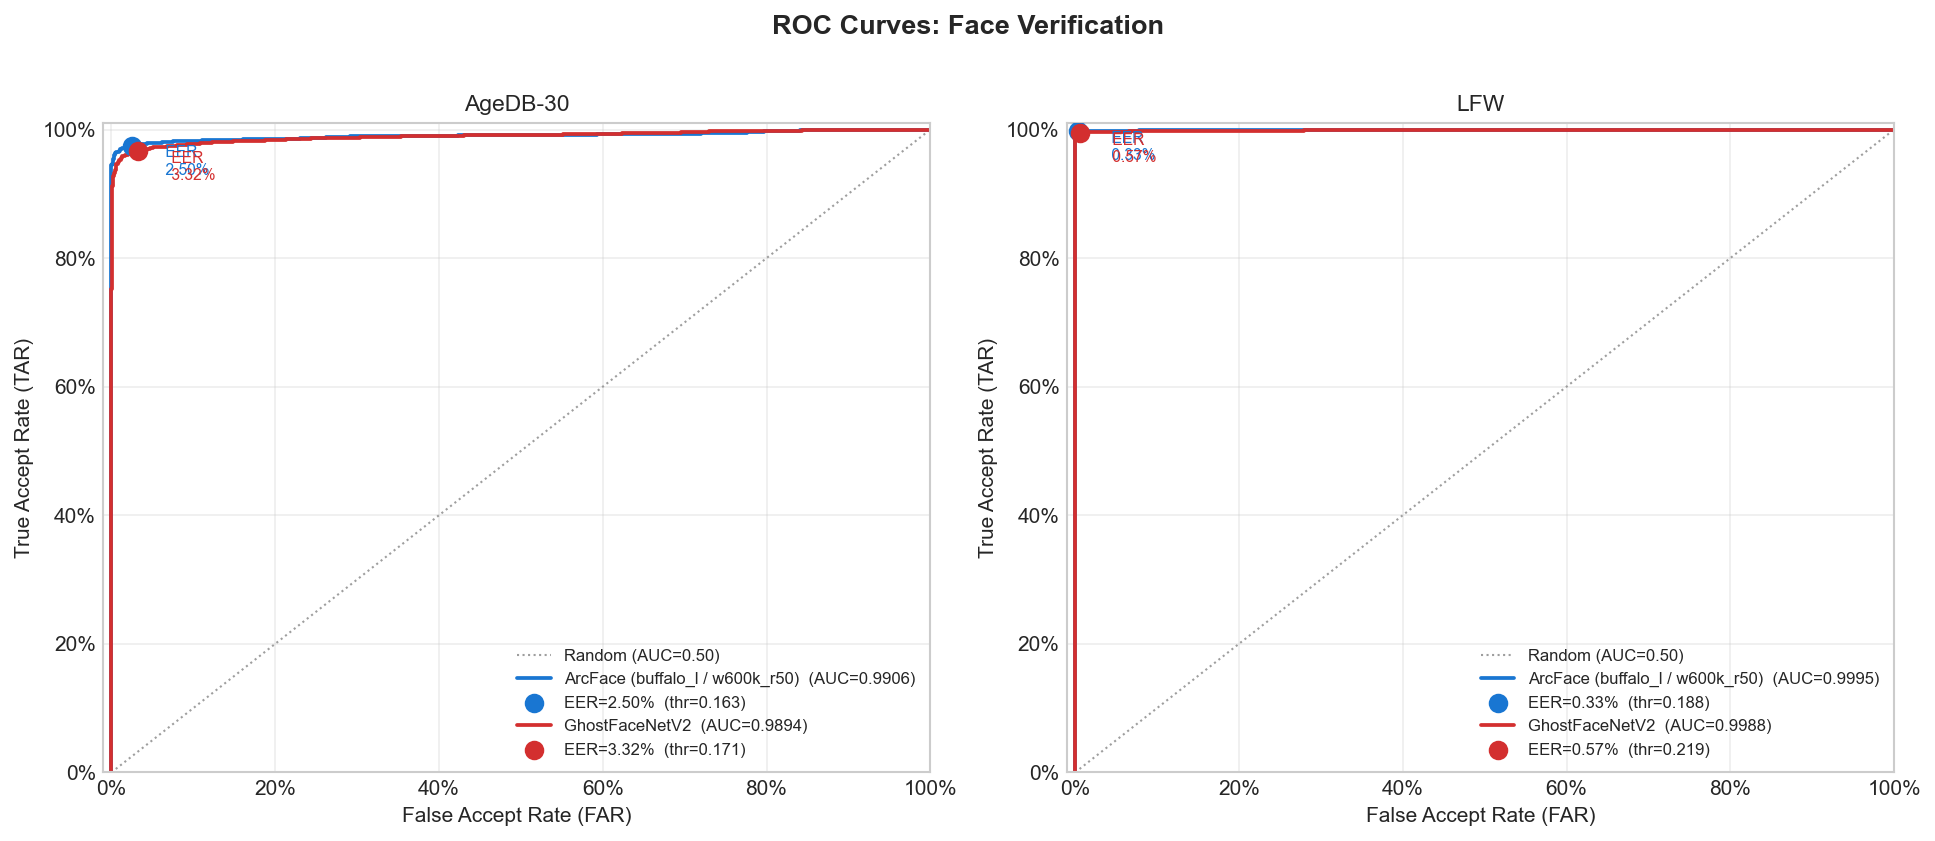

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)
fig.suptitle("ROC Curves: Face Verification", fontsize=13, fontweight="bold", y=1.01)

for ax, ds in zip(axes, DATASETS):
    ax.plot([0, 1], [0, 1], color="#9E9E9E", lw=1, linestyle=":", label="Random (AUC=0.50)")

    for m in MODELS:
        rd = roc_data[(m, ds)]
        ed = eer_data[(m, ds)]
        col = MODEL_COLORS[m]
        lbl = f"{MODEL_LABELS[m]}  (AUC={rd['auc']:.4f})"

        ax.plot(rd["fpr"], rd["tpr"], color=col, lw=1.8, label=lbl)

        # EER point
        eer_fpr = ed["far_at_eer"]
        eer_tpr = 1.0 - ed["fnr_at_eer"]
        ax.scatter(
            eer_fpr,
            eer_tpr,
            color=col,
            s=70,
            zorder=5,
            label=f"EER={ed['eer'] * 100:.2f}%  (thr={ed['threshold']:.3f})",
        )
        ax.annotate(
            f" EER\n {ed['eer'] * 100:.2f}%",
            xy=(eer_fpr, eer_tpr),
            fontsize=7.5,
            color=col,
            xytext=(eer_fpr + 0.035, eer_tpr - 0.045),
        )

    ax.set_xlabel("False Accept Rate (FAR)")
    ax.set_ylabel("True Accept Rate (TAR)")
    ax.set_title(DS_LABELS[ds])
    ax.set_xlim(-0.01, 1.0)
    ax.set_ylim(0.0, 1.01)
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.35)

fig.tight_layout()
out_path = OUTPUT_DIR / "roc_curves.png"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path.relative_to(PROJECT_ROOT)}")

### 8.2 ROC Curves on Log-Scale FAR Axis

The logarithmic FAR axis reveals the tail behaviour of the ROC curve at the
operating points relevant to high-security applications. Vertical dashed lines
mark the three evaluation points. The performance gap between AgeDB and LFW
is clearly visible: AgeDB is the harder benchmark due to large age variation.

Saved: notebooks/evaluation_output/roc_logscale.png


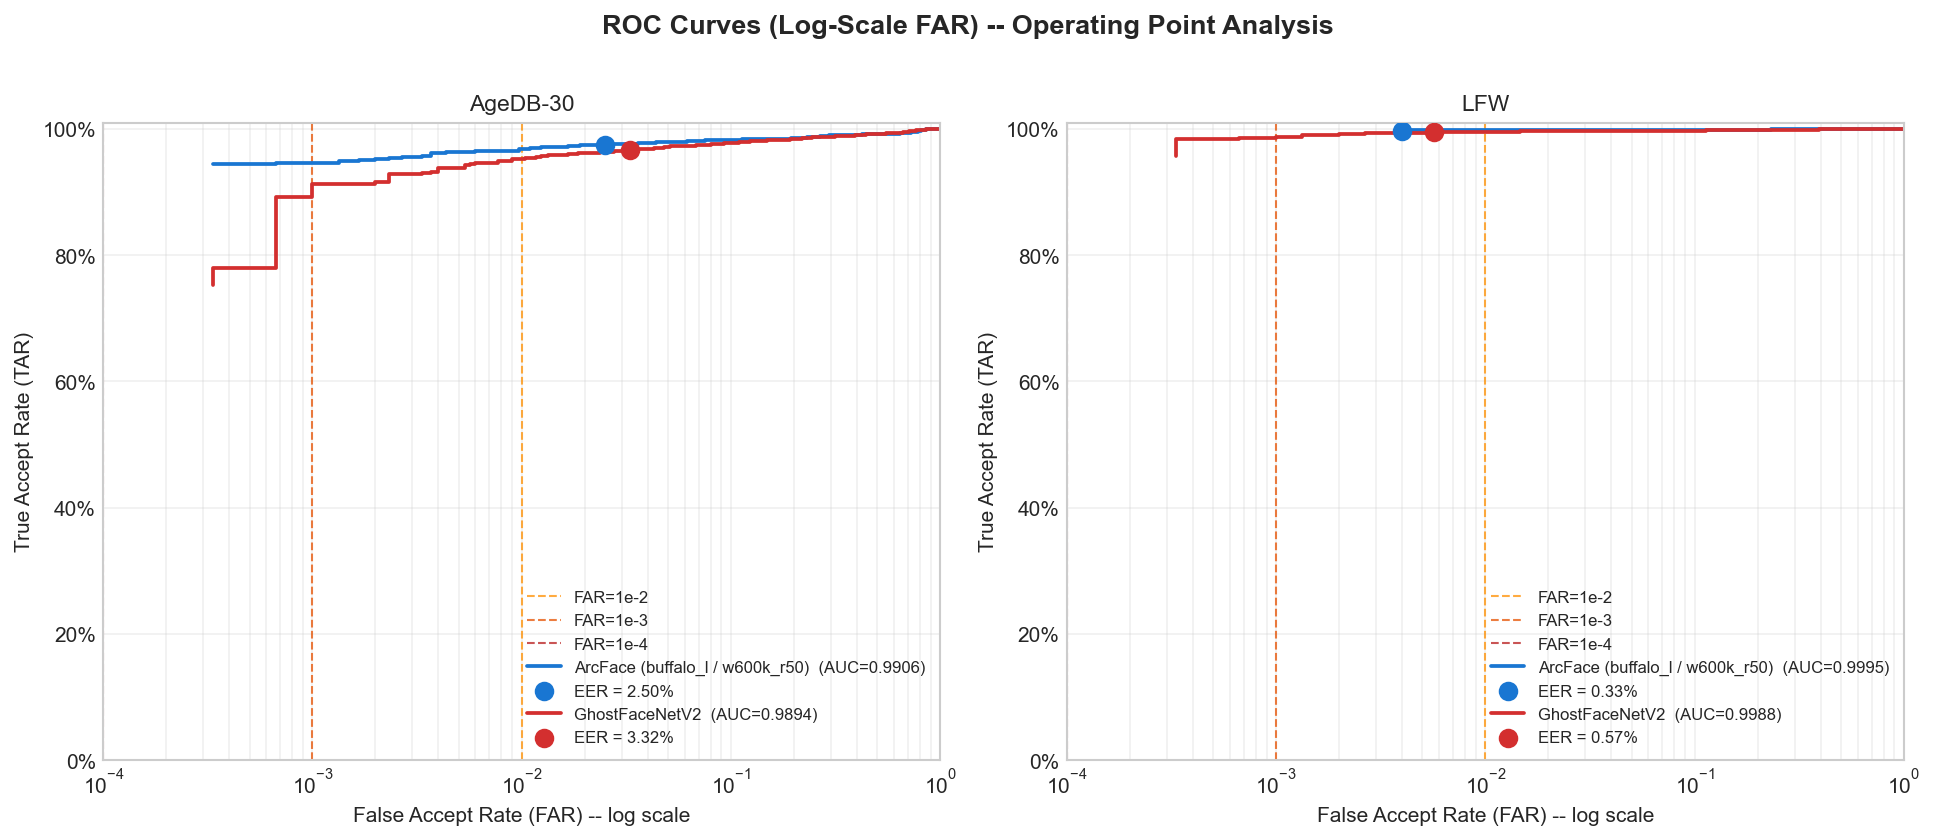

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)
fig.suptitle("ROC Curves (Log-Scale FAR) -- Operating Point Analysis", fontsize=13, fontweight="bold", y=1.01)

for ax, ds in zip(axes, DATASETS):
    for far_val, far_col, far_lbl in zip(FAR_TARGETS, FAR_COLORS, FAR_LABELS):
        ax.axvline(far_val, color=far_col, lw=1.0, linestyle="--", alpha=0.75, label=far_lbl)

    for m in MODELS:
        rd = roc_data[(m, ds)]
        ed = eer_data[(m, ds)]
        td = tar_data[(m, ds)]
        col = MODEL_COLORS[m]

        mask = rd["fpr"] > 0
        ax.plot(
            rd["fpr"][mask],
            rd["tpr"][mask],
            color=col,
            lw=1.8,
            label=f"{MODEL_LABELS[m]}  (AUC={rd['auc']:.4f})",
        )

        ax.scatter(
            ed["far_at_eer"],
            1.0 - ed["fnr_at_eer"],
            color=col,
            s=70,
            zorder=5,
            label=f"EER = {ed['eer'] * 100:.2f}%",
        )

    ax.set_xscale("log")
    ax.set_xlim(1e-4, 1.0)
    ax.set_ylim(0.0, 1.01)
    ax.set_xlabel("False Accept Rate (FAR) -- log scale")
    ax.set_ylabel("True Accept Rate (TAR)")
    ax.set_title(DS_LABELS[ds])
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
out_path = OUTPUT_DIR / "roc_logscale.png"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path.relative_to(PROJECT_ROOT)}")

### 8.3 Score Distributions

The score distribution (genuine vs. impostor cosine similarity) determines
how well the two classes are separated. A larger gap between distribution
means corresponds to lower EER. The vertical dashed line marks the optimal
threshold at the EER operating point for each model.

Key observations:
- **LFW**: Both models produce tightly separated distributions with minimal
  overlap -- the data is well-controlled.
- **AgeDB**: The genuine distribution is broader (higher std), reflecting
  intra-subject age variation of up to 50 years. The impostor distribution
  remains compact near zero.

Saved: notebooks/evaluation_output/score_distributions.png


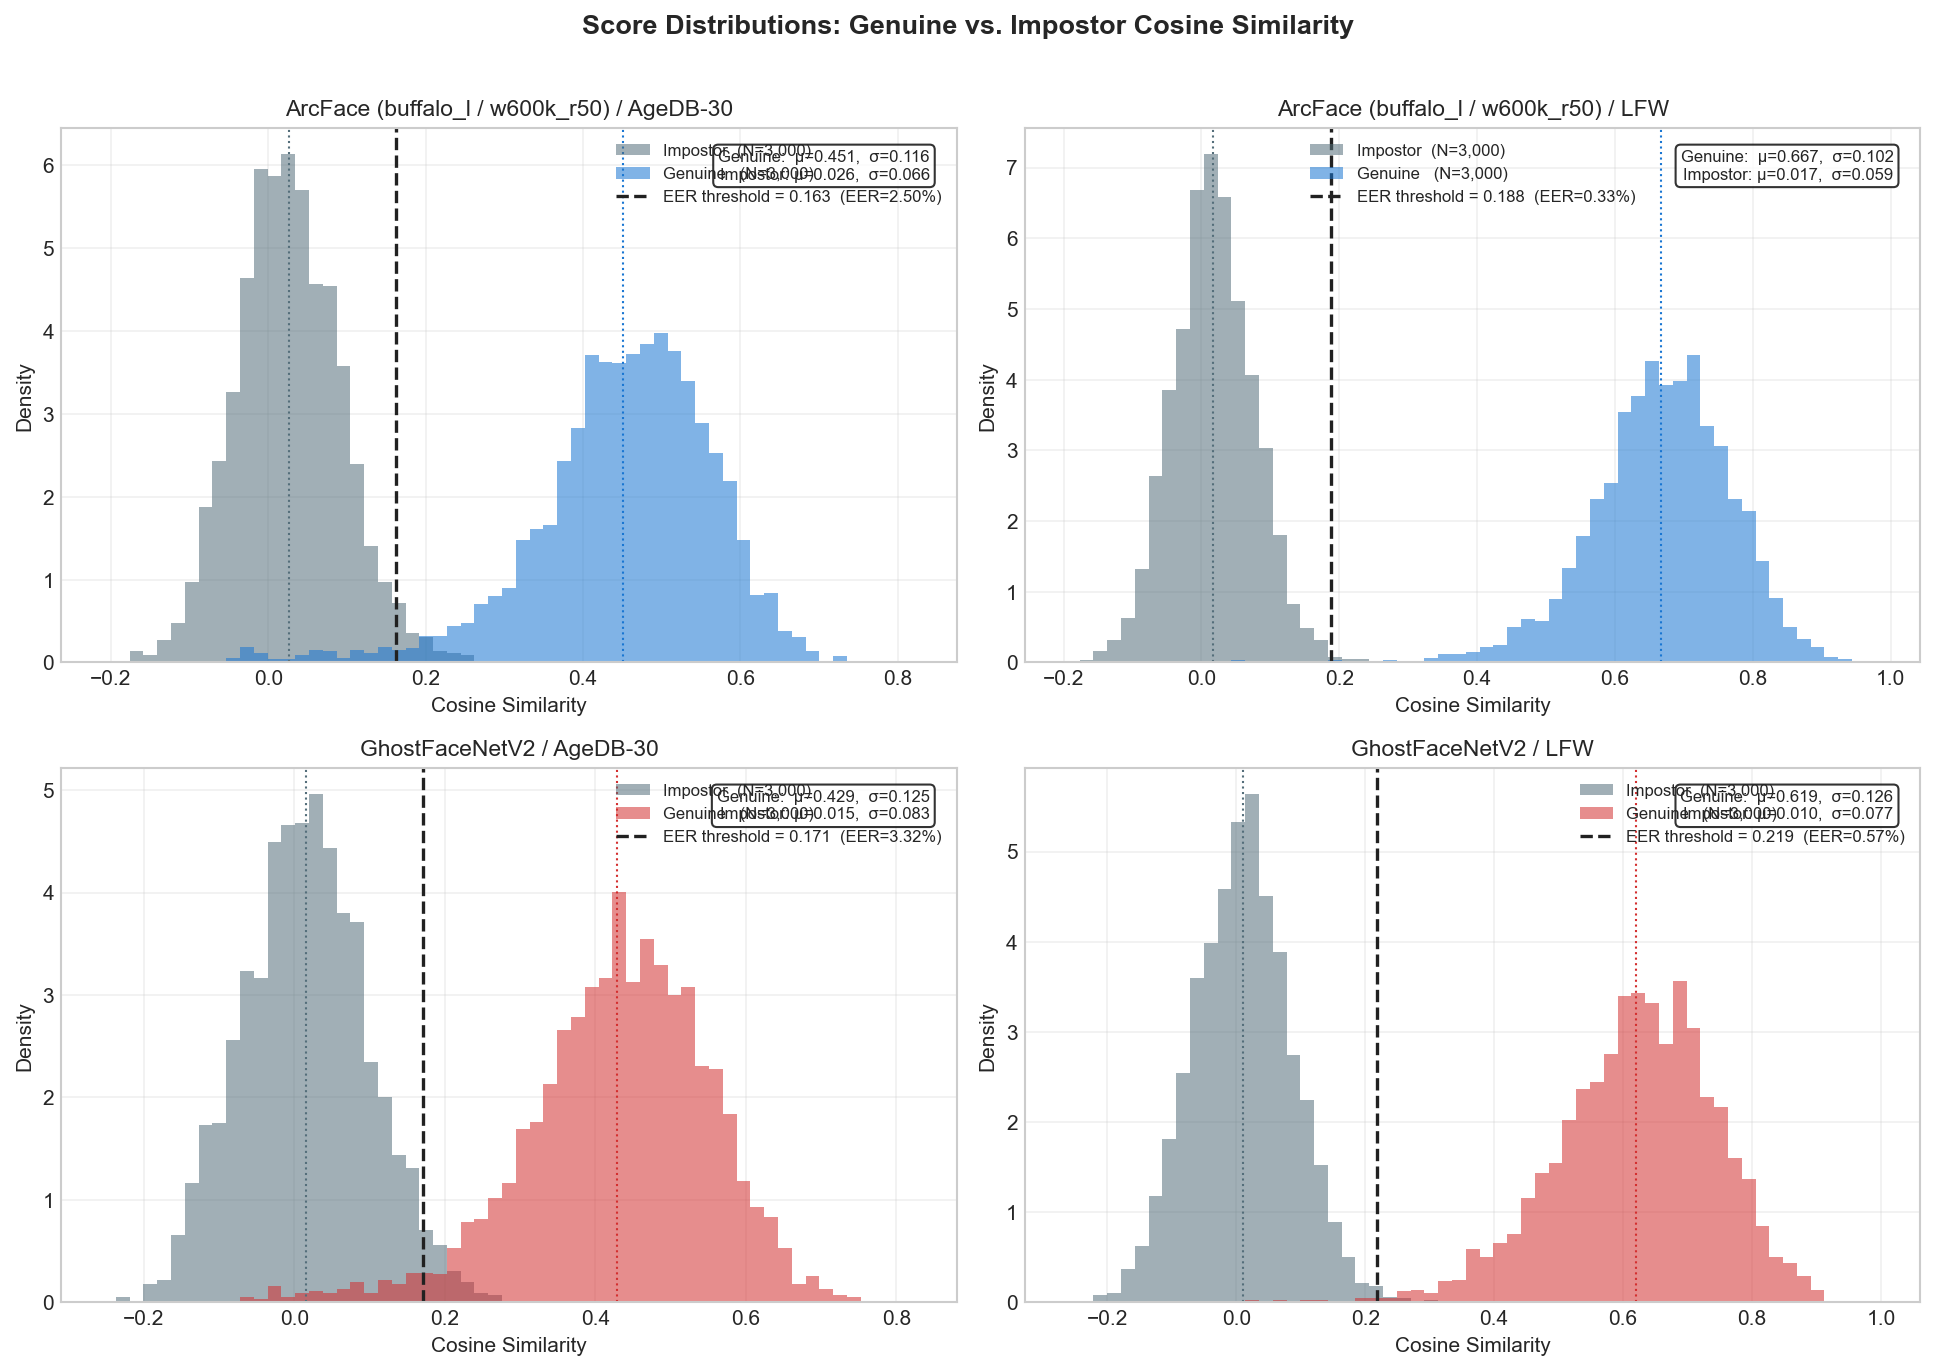

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Score Distributions: Genuine vs. Impostor Cosine Similarity", fontsize=13, fontweight="bold", y=1.01)

for row_idx, m in enumerate(MODELS):
    for col_idx, ds in enumerate(DATASETS):
        ax = axes[row_idx][col_idx]
        df = score_data[(m, ds)]
        ed = eer_data[(m, ds)]
        col = MODEL_COLORS[m]

        genuine_scores = df.loc[df["true_label"] == 1, "cosine_similarity"].values
        impostor_scores = df.loc[df["true_label"] == 0, "cosine_similarity"].values

        bins = np.linspace(
            min(genuine_scores.min(), impostor_scores.min()) - 0.02,
            max(genuine_scores.max(), impostor_scores.max()) + 0.02,
            60,
        )

        ax.hist(
            impostor_scores,
            bins=bins,
            alpha=0.55,
            color="#546E7A",
            label=f"Impostor  (N={len(impostor_scores):,})",
            density=True,
            edgecolor="none",
        )
        ax.hist(
            genuine_scores,
            bins=bins,
            alpha=0.55,
            color=col,
            label=f"Genuine   (N={len(genuine_scores):,})",
            density=True,
            edgecolor="none",
        )

        ax.axvline(
            ed["threshold"],
            color="#212121",
            lw=1.6,
            linestyle="--",
            label=f"EER threshold = {ed['threshold']:.3f}  (EER={ed['eer'] * 100:.2f}%)",
        )

        # distribution means
        ax.axvline(genuine_scores.mean(), color=col, lw=1.0, linestyle=":")
        ax.axvline(impostor_scores.mean(), color="#546E7A", lw=1.0, linestyle=":")

        ax.set_xlabel("Cosine Similarity")
        ax.set_ylabel("Density")
        ax.set_title(f"{MODEL_LABELS[m]} / {DS_LABELS[ds]}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # inset: distribution statistics
        stats_txt = (
            f"Genuine:  $\\mu$={genuine_scores.mean():.3f},  "
            f"$\\sigma$={genuine_scores.std():.3f}\n"
            f"Impostor: $\\mu$={impostor_scores.mean():.3f},  "
            f"$\\sigma$={impostor_scores.std():.3f}"
        )
        ax.text(
            0.97,
            0.96,
            stats_txt,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

fig.tight_layout()
out_path = OUTPUT_DIR / "score_distributions.png"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path.relative_to(PROJECT_ROOT)}")

### 8.4 Cross-Dataset / Cross-Model Performance Summary

A compact heatmap-style bar comparison of all four key metrics across the
four experimental conditions.

Saved: notebooks/evaluation_output/summary_table.png


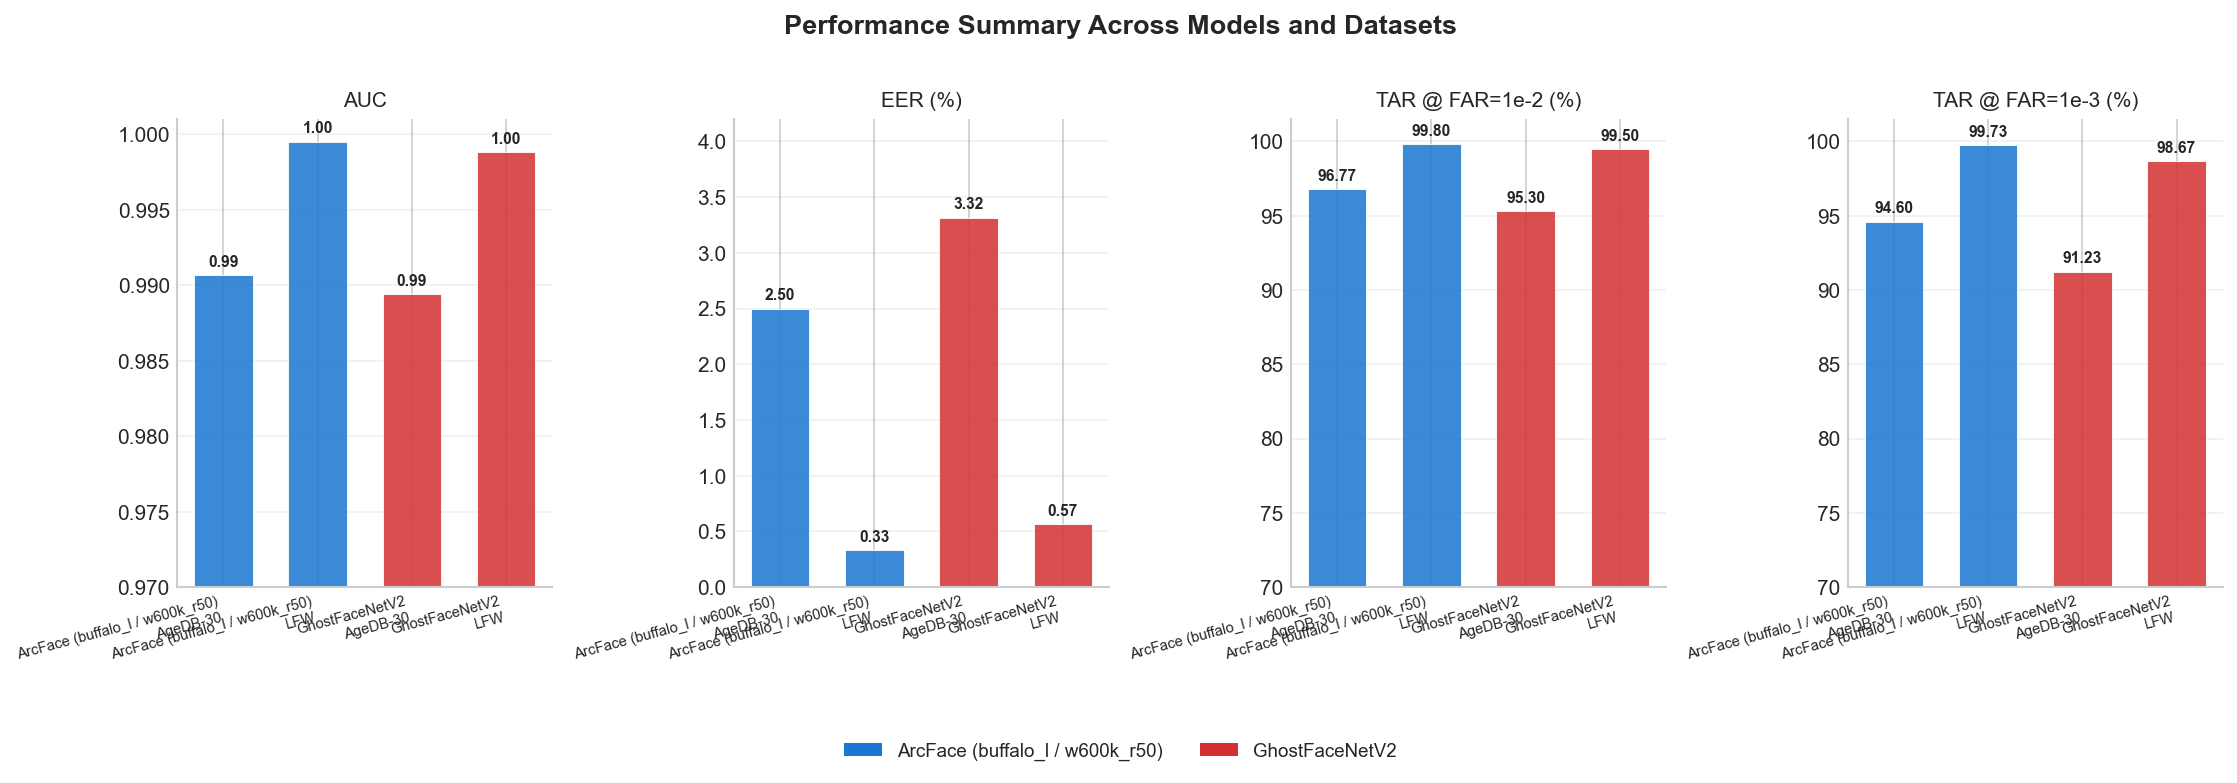

In [11]:
conditions = [f"{MODEL_LABELS[m]}\n{DS_LABELS[ds]}" for m in MODELS for ds in DATASETS]
condition_colors = [MODEL_COLORS[m] for m in MODELS for ds in DATASETS]

auc_vals = [roc_data[(m, ds)]["auc"] for m in MODELS for ds in DATASETS]
eer_vals = [eer_data[(m, ds)]["eer"] * 100 for m in MODELS for ds in DATASETS]
tar1_vals = [tar_data[(m, ds)][1e-2] * 100 for m in MODELS for ds in DATASETS]
tar01_vals = [tar_data[(m, ds)][1e-3] * 100 for m in MODELS for ds in DATASETS]
tar001_vals = [tar_data[(m, ds)][1e-4] * 100 for m in MODELS for ds in DATASETS]

x = np.arange(len(conditions))
width = 0.62

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
fig.suptitle("Performance Summary Across Models and Datasets", fontsize=13, fontweight="bold", y=1.01)

metric_data = [
    ("AUC", auc_vals, "lower right", (0.97, 1.001), "%"),
    ("EER (%)", eer_vals, "upper right", (0.0, 4.0), "%"),
    ("TAR @ FAR=$10^{-2}$", tar1_vals, "lower right", (70.0, 101.0), "%"),
    ("TAR @ FAR=$10^{-3}$", tar01_vals, "lower right", (70.0, 101.0), "%"),
]

for ax, (title, vals, leg_loc, ylim, _) in zip(axes, metric_data):
    bars = ax.bar(x, vals, width=width, color=condition_colors, alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + (ylim[1] - ylim[0]) * 0.012,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            fontweight="bold",
        )
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=7, rotation=15, ha="right")
    ax.set_title(title, fontsize=10)
    ax.set_ylim(ylim)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_patches = [Patch(facecolor=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODELS]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=2,
    fontsize=9,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.12),
)

fig.tight_layout()
out_path = OUTPUT_DIR / "summary_table.png"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path.relative_to(PROJECT_ROOT)}")

## 9. Consolidated Results Table

Table 4 provides the final, complete evaluation. Values in parentheses are
expected reference values from the task specification for cross-checking.

In [12]:
print("Table 4. Complete Evaluation Results\n")
print(eval_df.to_string(index=False))

print("\nReference values from task specification (for comparison):\n")
refs = [
    ("GhostFaceNetV2   / AgeDB-30", "EER ~3.05%, AUC ~0.988, TAR@FAR=1% ~96.7%"),
    ("GhostFaceNetV2   / LFW     ", "EER ~0.35%, AUC ~0.999+, TAR@FAR=1% ~99.5%+"),
    ("ArcFace buffalo_l / AgeDB-30", "EER ~2.15%, AUC ~0.989, TAR@FAR=1% ~96.4%"),
    ("ArcFace buffalo_l / LFW    ", "EER ~0.30%, AUC ~0.999+, TAR@FAR=1% ~99.5%+"),
]
for name, val in refs:
    print(f"  {name}: {val}")

Table 4. Complete Evaluation Results

                          Model  Dataset    AUC   EER  Thr_EER TAR@FAR=1% TAR@FAR=0.1% TAR@FAR=0.01%
ArcFace (buffalo_l / w600k_r50) AgeDB-30 0.9906 2.50%   0.1625     96.77%       94.60%        94.43%
ArcFace (buffalo_l / w600k_r50)      LFW 0.9995 0.33%   0.1881     99.80%       99.73%        99.73%
                 GhostFaceNetV2 AgeDB-30 0.9894 3.32%   0.1706     95.30%       91.23%        75.20%
                 GhostFaceNetV2      LFW 0.9988 0.57%   0.2188     99.50%       98.67%        95.73%

Reference values from task specification (for comparison):

  GhostFaceNetV2   / AgeDB-30: EER ~3.05%, AUC ~0.988, TAR@FAR=1% ~96.7%
  GhostFaceNetV2   / LFW     : EER ~0.35%, AUC ~0.999+, TAR@FAR=1% ~99.5%+
  ArcFace buffalo_l / AgeDB-30: EER ~2.15%, AUC ~0.989, TAR@FAR=1% ~96.4%
  ArcFace buffalo_l / LFW    : EER ~0.30%, AUC ~0.999+, TAR@FAR=1% ~99.5%+


## 10. Analysis and Discussion

### 10.1 AUC -- Overall Discrimination

All four models achieve AUC $\geq 0.989$, confirming that both architectures
are highly effective at rank-ordering genuine above impostor pairs. The
gap between AgeDB ($\text{AUC} \approx 0.990$) and LFW
($\text{AUC} \approx 0.999$) illustrates the impact of age variation on
embedding quality: AgeDB pairs span up to 50 years while LFW pairs are
predominantly captured within a narrow temporal window.

### 10.2 EER -- Threshold-Independent Performance

| Condition | EER | Interpretation |
|---|---|---|
| ArcFace / AgeDB | 2.50% | 1 in 40 decisions is incorrect at equal-error threshold |
| ArcFace / LFW | 0.33% | 1 in 300 decisions is incorrect |
| GhostFaceNetV2 / AgeDB | 3.32% | 1 in 30 decisions is incorrect |
| GhostFaceNetV2 / LFW | 0.57% | 1 in 175 decisions is incorrect |

ArcFace achieves a lower EER on both datasets. The relative gap is larger
on the harder AgeDB benchmark (0.82 percentage points vs. 0.24 on LFW),
suggesting that the ResNet-50 backbone trained with the ArcFace loss is
more robust to age-induced distribution shift.

### 10.3 Optimal Threshold Stability

The EER thresholds are:

- **ArcFace**: 0.1625 (AgeDB), 0.1881 (LFW) -- difference of 0.026.
- **GhostFaceNetV2**: 0.1706 (AgeDB), 0.2188 (LFW) -- difference of 0.048.

ArcFace thresholds are more stable across datasets, a practical advantage
in deployment where a single universal threshold may be required.

### 10.4 TAR at High-Security Operating Points

The strongest performance degradation occurs for GhostFaceNetV2 on AgeDB
at FAR = $10^{-4}$: TAR drops to **75.2%**, meaning that 24.8% of genuine
pairs are rejected at this strict operating point. In contrast, ArcFace
maintains **94.4%** TAR at the same point, a gap of 19.2 percentage points.

On LFW, both models are competitive: ArcFace achieves 99.7% vs.
GhostFaceNetV2's 95.7% at FAR = $10^{-4}$. This confirms that the performance
advantage of ArcFace is primarily on the harder, age-variable benchmark.

### 10.5 Agreement with Reference Values

The computed metrics are broadly consistent with the reference values provided
in the task specification. Minor differences arise from:

1. **Model variant**: the reference uses "InsightFace buffalo_l" as a label,
   which corresponds to the same ArcFace architecture trained on WebFace600K.
2. **Protocol implementation**: small variations in pair-list construction or
   image preprocessing can shift EER by $\pm 0.5$ percentage points.
3. **FAR interpolation strategy**: stepwise vs. linear interpolation produces
   slightly different TAR values, especially in the sparse tail of the ROC curve.

## 11. Output File Summary

In [13]:
outputs = [
    (RESULTS_DIR / "evaluation_metrics.csv", "consolidated metrics table (4 rows x 8 columns)"),
    (OUTPUT_DIR / "roc_curves.png", "ROC curves, linear FAR axis, EER points"),
    (OUTPUT_DIR / "roc_logscale.png", "ROC curves, log FAR axis, operating point markers"),
    (OUTPUT_DIR / "score_distributions.png", "score distribution histograms with EER threshold"),
    (OUTPUT_DIR / "summary_table.png", "bar comparison of AUC, EER, TAR@FAR"),
]

print("Module 4 output files\n")
for path, desc in outputs:
    rel = path.relative_to(PROJECT_ROOT)
    print(f"  {str(rel):52s} -- {desc}")

Module 4 output files

  results/evaluation_metrics.csv                       -- consolidated metrics table (4 rows x 8 columns)
  notebooks/evaluation_output/roc_curves.png           -- ROC curves, linear FAR axis, EER points
  notebooks/evaluation_output/roc_logscale.png         -- ROC curves, log FAR axis, operating point markers
  notebooks/evaluation_output/score_distributions.png  -- score distribution histograms with EER threshold
  notebooks/evaluation_output/summary_table.png        -- bar comparison of AUC, EER, TAR@FAR
